### Get File Paths

In [2]:
import os
import pandas as pd
import re

csi_directory = "../data_capture/csi/top_csi_filtered"
audio_directory = "../data_capture/audio_matrix"

# Helper to extract timestamp from filename
def extract_timestamp(filename):
    # For audio: 2025-05-07_20-11-50.303.csv
    # For csi: top8_filtered_csi_data_2025-05-07_20-11-50.303.csv
    match = re.search(r'(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2}\.\d+)', filename)
    return match.group(1) if match else None

# Build lookup for CSI files by timestamp
csi_files = [f for f in os.listdir(csi_directory) if f.startswith('top8_filtered_csi_data_') and f.endswith('.csv')]
csi_timestamps = {extract_timestamp(f): f for f in csi_files}

audio_files = [f for f in os.listdir(audio_directory) if f.endswith('.csv')]
audio_timestamps = {extract_timestamp(f): f for f in audio_files}

# Find common timestamps
common_timestamps = sorted(set(csi_timestamps) & set(audio_timestamps))

if len(common_timestamps) < len(csi_timestamps) or len(common_timestamps) < len(audio_timestamps):
    print(f"Warning: Only {len(common_timestamps)} matched pairs found. Some files are missing their pair.")

data = []
for ts in common_timestamps:
    csi_file = csi_timestamps[ts]
    audio_file = audio_timestamps[ts]
    data.append({
        "csi_path": os.path.join(csi_directory, csi_file),
        "audio_path": os.path.join(audio_directory, audio_file)
    })

df = pd.DataFrame(data)
output_path = "data_paths.csv"
df.to_csv(output_path, index=False)
print(f"Dataset CSV created at {output_path} with {len(df)} matched pairs.")

Dataset CSV created at data_paths.csv with 44 matched pairs.


### Get the required libraries

In [3]:
import os
import torch
import logging
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Rectangle
from matplotlib.sankey import Sankey
import soundfile as sf

### Hyperparameters and Dataset Class

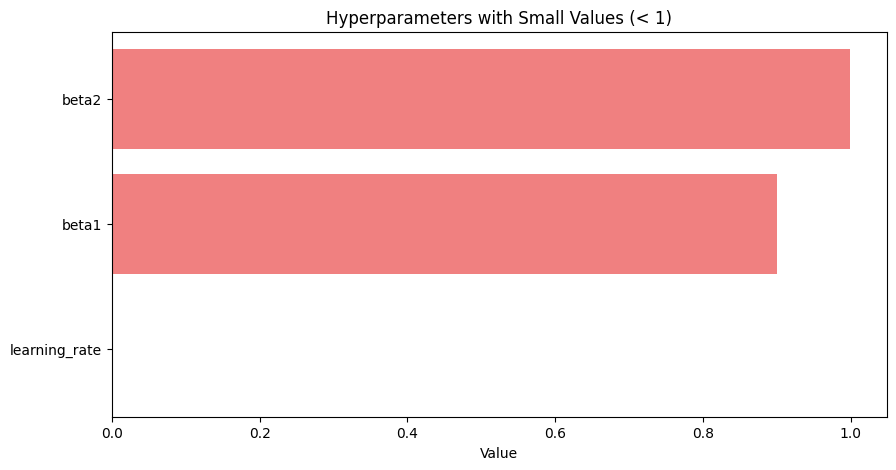

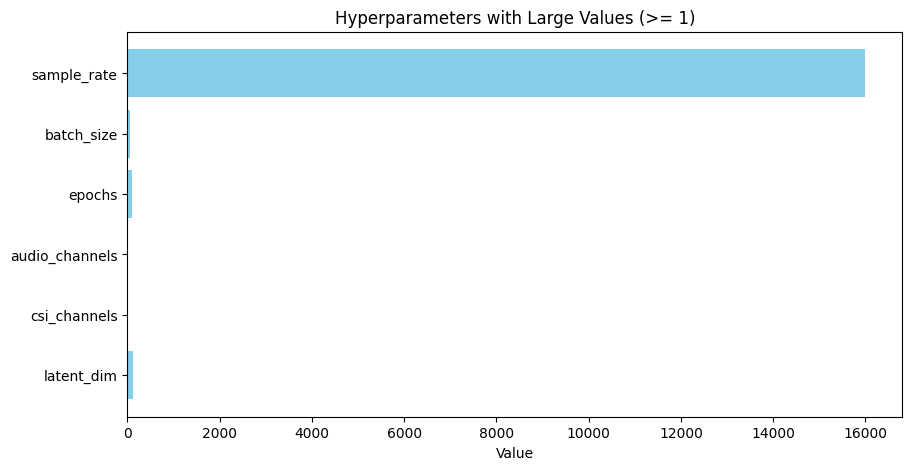

In [4]:

# Hyperparameters
latent_dim = 128            # Increase latent dimension for richer representations
csi_channels = 1            # Keep as is (depends on input data)
audio_channels = 1          # Keep as is (depends on input data)
epochs = 100                # Reduce epochs to avoid overfitting (can be adjusted if data is sufficient)
batch_size = 64             # Increase batch size for more stable gradients
learning_rate = 0.0002      # Slightly increase learning rate for faster convergence
beta1 = 0.9                 # Update for improved stability of Adam optimizer
beta2 = 0.999               # Keep as is (default value for Adam optimizer)
sample_rate = 16000         # Keep as is (dependent on your audio data)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def visualize_hyperparameters(params):
    # Split the parameters into two categories: small values and large values
    small_values = {key: value for key, value in params.items() if value < 1}
    large_values = {key: value for key, value in params.items() if value >= 1}

    # Plot small values
    plt.figure(figsize=(10, 5))
    if small_values:
        names = list(small_values.keys())
        values = list(small_values.values())
        plt.barh(names, values, color="lightcoral")
        plt.xlabel("Value")
        plt.title("Hyperparameters with Small Values (< 1)")
        plt.show()

    # Plot large values
    plt.figure(figsize=(10, 5))
    if large_values:
        names = list(large_values.keys())
        values = list(large_values.values())
        plt.barh(names, values, color="skyblue")
        plt.xlabel("Value")
        plt.title("Hyperparameters with Large Values (>= 1)")
        plt.show()

# Complete hyperparameters dictionary
hyperparameters = {
    "latent_dim": latent_dim,
    "csi_channels": csi_channels,
    "audio_channels": audio_channels,
    "epochs": epochs,
    "batch_size": batch_size,
    "learning_rate": learning_rate,
    "beta1": beta1,
    "beta2": beta2,
    "sample_rate": sample_rate
}

# Visualize hyperparameters
visualize_hyperparameters(hyperparameters)

# Dataset class
class CSIAudioDataset(Dataset):
    def __init__(self, data_df):
        self.data_df = data_df

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        logging.debug(f"Processing index: {idx}")
        csi_path = self.data_df.iloc[idx]['csi_path']
        csi_data = pd.read_csv(csi_path)
        subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]
        csi_data = csi_data[subcarrier_cols].values.T  # shape: (8, N)
        # Interpolate to 400 data points for each subcarrier
        target_len = 400
        csi_data_resampled = np.array([
            np.interp(
                np.linspace(0, len(channel) - 1, target_len),
                np.arange(len(channel)),
                channel
            ) for channel in csi_data
        ])
        csi_tensor = torch.tensor(csi_data_resampled, dtype=torch.float32)

        # Load audio data from CSV and interpolate
        audio_path = self.data_df.iloc[idx]['audio_path']
        audio_data = pd.read_csv(audio_path, header=None).values.flatten()
        audio_data_resampled = np.interp(
            np.linspace(0, len(audio_data) - 1, target_len),
            np.arange(len(audio_data)),
            audio_data
        )
        audio_tensor = torch.tensor(audio_data_resampled, dtype=torch.float32)

        # Trim tensors to the same length
        min_len = min(csi_tensor.shape[1], len(audio_tensor))
        if min_len == 0:
            logging.warning(f"No valid audio length for index: {idx}")
            return None

        csi_tensor_trimmed = csi_tensor[:, :min_len]
        audio_trimmed = audio_tensor[:min_len]
        return csi_tensor_trimmed, audio_trimmed
        


### Data Loading

In [5]:
# Load dataset
train_df = pd.read_csv("data_paths.csv")  # change this to actually load data ()
train_dataset = CSIAudioDataset(train_df)

# Filter out None values
train_loader = DataLoader(
    [data for data in train_dataset if data is not None],
    batch_size=batch_size,
    shuffle=True
)



### Generator Model

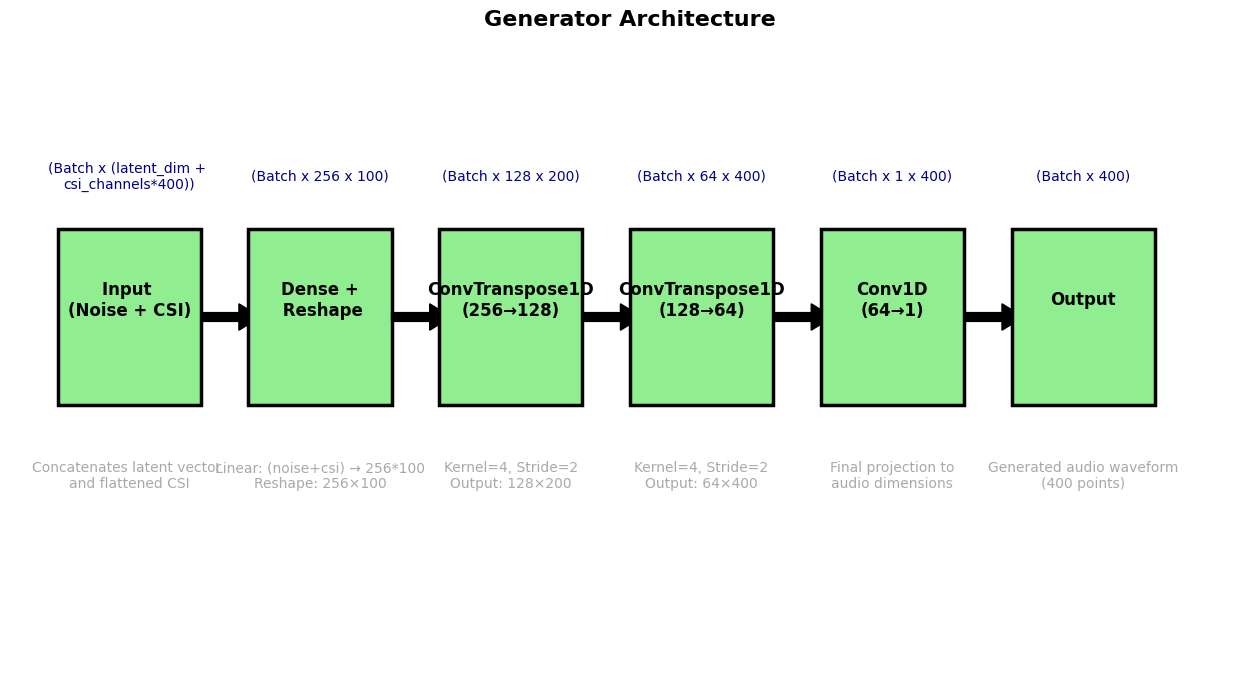

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim, csi_channels, audio_channels=1, csi_length=400):
        super(Generator, self).__init__()
        input_dim = latent_dim + csi_channels * csi_length  # Total input dimension after concatenation
        self.fc = nn.Linear(input_dim, 256 * 100)  # Project to 256 channels with 100 time steps

        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)  # Final projection to audio

    def forward(self, z, csi_data):
        # Flatten CSI data
        csi_flat = csi_data.view(csi_data.size(0), -1)
        
        # Concatenate latent vector and flattened CSI data
        x = torch.cat([z, csi_flat], dim=1)
        
        # Project to the correct shape for transposed convolutions
        x = self.fc(x).view(-1, 256, 100)  # Reshape to (batch_size, channels, time_steps)
        
        # Apply transposed convolutions
        x = F.relu(self.conv1(x))  # Output: (batch_size, 128, 200)
        x = F.relu(self.conv2(x))  # Output: (batch_size, 64, 400)
        x = self.conv3(x)          # Output: (batch_size, 1, 400)
        
        return torch.sigmoid(x.view(-1, 400))  # Reshape to (batch_size, 400)

def visualize_generator_architecture():
    fig, ax = plt.subplots(figsize=(16, 8))

    # Updated layers for corrected generator
    layers = [
        {"name": "Input \n(Noise + CSI)", "desc": "Concatenates latent vector \nand flattened CSI", "pos": (0, 0), "size": (3, 2)},
        {"name": "Dense +\n Reshape", "desc": "Linear: (noise+csi) → 256*100\nReshape: 256×100", "pos": (4, 0), "size": (3, 2)},
        {"name": "ConvTranspose1D\n(256→128)", "desc": "Kernel=4, Stride=2\nOutput: 128×200", "pos": (8, 0), "size": (3, 2)},
        {"name": "ConvTranspose1D\n(128→64)", "desc": "Kernel=4, Stride=2\nOutput: 64×400", "pos": (12, 0), "size": (3, 2)},
        {"name": "Conv1D\n(64→1)", "desc": "Final projection to\naudio dimensions", "pos": (16, 0), "size": (3, 2)},
        {"name": "Output", "desc": "Generated audio waveform\n(400 points)", "pos": (20, 0), "size": (3, 2)}
    ]
    
    # Updated data shapes
    data_shapes = [
        "(Batch x (latent_dim + \ncsi_channels*400))",
        "(Batch x 256 x 100)",
        "(Batch x 128 x 200)",
        "(Batch x 64 x 400)",
        "(Batch x 1 x 400)",
        "(Batch x 400)"
    ]
    
    # Draw layers and arrows
    for i, layer in enumerate(layers):
        # Draw the layer block
        rect = Rectangle(layer["pos"], *layer["size"], edgecolor="black", facecolor="lightgreen", linewidth=2.5)
        ax.add_patch(rect)
        
        # Layer name
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] / 2 + 0.2,
            layer["name"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=12,
            fontweight="bold"
        )
        
        # Layer description
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] - 0.8,
            layer["desc"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkgray"
        )
        
        # Data shape
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] + 0.6,
            data_shapes[i],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkblue"
        )
        
        # Draw arrow to the next layer
        if i < len(layers) - 1:
            start_x = layer["pos"][0] + layer["size"][0]
            start_y = layer["pos"][1] + layer["size"][1] / 2
            end_x = layers[i + 1]["pos"][0]
            end_y = layers[i + 1]["pos"][1] + layers[i + 1]["size"][1] / 2
            arrow = FancyArrow(start_x, start_y, end_x - start_x - 0.2, end_y - start_y, width=0.1, color="black")
            ax.add_patch(arrow)

    # Adjust axes
    ax.set_xlim(-1, 25)
    ax.set_ylim(-3, 4)
    ax.axis("off")
    ax.set_title("Generator Architecture", fontsize=16, fontweight="bold", pad=20)
    plt.show()

visualize_generator_architecture()



### Discriminator Model

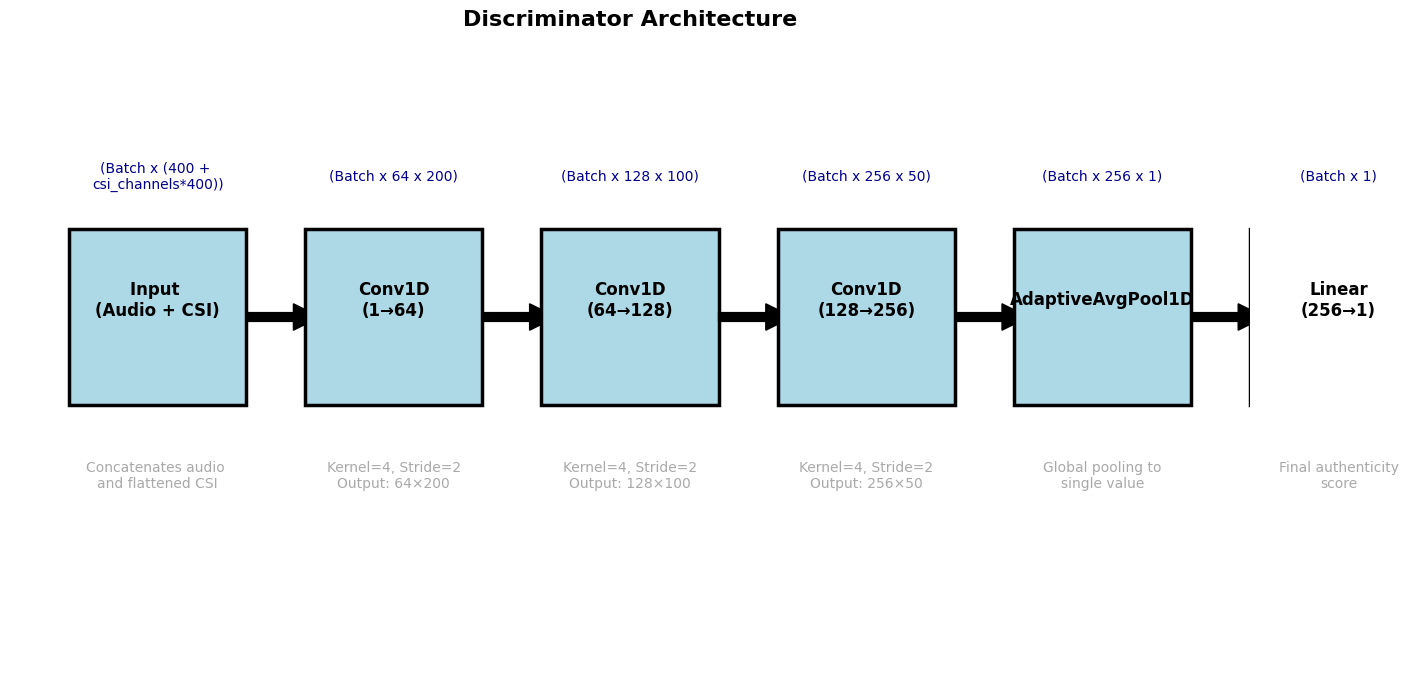

In [7]:
class Discriminator(nn.Module):
    def __init__(self, csi_channels):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, 1)
    
    def forward(self, audio, csi):
        csi_flat = csi.view(csi.size(0), -1)
        x = torch.cat([audio, csi_flat], dim=1).unsqueeze(1)  # [batch, 1, L]
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)  # [batch, 256]
        return torch.sigmoid(self.fc(x))  # [batch, 1]


def visualize_discriminator_architecture():
    fig, ax = plt.subplots(figsize=(16, 8))

    # Updated layers for corrected discriminator
    layers = [
        {"name": "Input \n(Audio + CSI)", "desc": "Concatenates audio \nand flattened CSI", "pos": (0, 0), "size": (3, 2)},
        {"name": "Conv1D\n(1→64)", "desc": "Kernel=4, Stride=2\nOutput: 64×200", "pos": (4, 0), "size": (3, 2)},
        {"name": "Conv1D\n(64→128)", "desc": "Kernel=4, Stride=2\nOutput: 128×100", "pos": (8, 0), "size": (3, 2)},
        {"name": "Conv1D\n(128→256)", "desc": "Kernel=4, Stride=2\nOutput: 256×50", "pos": (12, 0), "size": (3, 2)},
        {"name": "AdaptiveAvgPool1D", "desc": "Global pooling to\nsingle value", "pos": (16, 0), "size": (3, 2)},
        {"name": "Linear\n(256→1)", "desc": "Final authenticity\nscore", "pos": (20, 0), "size": (3, 2)}
    ]
    
    # Updated data shapes
    data_shapes = [
        "(Batch x (400 + \ncsi_channels*400))",
        "(Batch x 64 x 200)",
        "(Batch x 128 x 100)",
        "(Batch x 256 x 50)",
        "(Batch x 256 x 1)",
        "(Batch x 1)"
    ]

    
    # Draw layers and arrows
    for i, layer in enumerate(layers):
        # Draw the layer block
        rect = Rectangle(layer["pos"], *layer["size"], edgecolor="black", facecolor="lightblue", linewidth=2.5)
        ax.add_patch(rect)
        
        # Layer name
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] / 2 + 0.2,
            layer["name"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=12,
            fontweight="bold"
        )
        
        # Layer description
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] - 0.8,
            layer["desc"],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkgray"
        )
        
        # Data shape
        ax.text(
            layer["pos"][0] + layer["size"][0] / 2,
            layer["pos"][1] + layer["size"][1] + 0.6,
            data_shapes[i],
            horizontalalignment="center",
            verticalalignment="center",
            fontsize=10,
            color="darkblue"
        )
        
        # Draw arrow to the next layer
        if i < len(layers) - 1:
            start_x = layer["pos"][0] + layer["size"][0]
            start_y = layer["pos"][1] + layer["size"][1] / 2
            end_x = layers[i + 1]["pos"][0]
            end_y = layers[i + 1]["pos"][1] + layers[i + 1]["size"][1] / 2
            arrow = FancyArrow(start_x, start_y, end_x - start_x - 0.2, end_y - start_y, width=0.1, color="black")
            ax.add_patch(arrow)

    # Adjust axes
    ax.set_xlim(-1, 20)
    ax.set_ylim(-3, 4)
    ax.axis("off")
    ax.set_title("Discriminator Architecture", fontsize=16, fontweight="bold", pad=20)
    plt.show()

visualize_discriminator_architecture()



### Loss Functions

In [8]:
def generator_loss(d_output):
    return F.binary_cross_entropy(d_output, torch.ones_like(d_output))

def discriminator_loss(d_output_real, d_output_fake):
    real_loss = F.binary_cross_entropy(d_output_real, torch.ones_like(d_output_real))
    fake_loss = F.binary_cross_entropy(d_output_fake, torch.zeros_like(d_output_fake))
    return real_loss + fake_loss


### Initialize Models and Optimizers

In [9]:
generator = Generator(latent_dim, csi_channels).to(device)
discriminator = Discriminator(csi_channels).to(device)

optimizer_g = optim.Adam(generator.parameters(), lr=learning_rate, betas=(beta1, beta2))
optimizer_d = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(beta1, beta2))


### Training Loop

In [10]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import logging
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    datefmt='%Y-%m-%d %H:%M:%S'
)

class WindowedTrainer:
    def __init__(self, generator, discriminator, dataset, hyperparameters):
        """
        Initialize the windowed trainer.
        
        Args:
            generator: Generator model
            discriminator: Discriminator model
            dataset: CSIAudioDataset instance
            hyperparameters: Dictionary containing training hyperparameters
        """
        self.generator = generator.to(hyperparameters['device'])
        self.discriminator = discriminator.to(hyperparameters['device'])
        self.dataset = dataset
        self.hyperparameters = hyperparameters
        
        # Initialize optimizers
        self.optimizer_g = torch.optim.Adam(
            self.generator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        self.optimizer_d = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        
        # Initialize data loader with collate function to handle None values
        self.train_loader = DataLoader(
            dataset,
            batch_size=hyperparameters['batch_size'],
            shuffle=True,
            drop_last=True,
            collate_fn=self.collate_fn
        )
        
        # Initialize lists for tracking losses
        self.d_losses = []
        self.g_losses = []
        
    @staticmethod
    def collate_fn(batch):
        """
        Custom collate function to handle None values and create proper batches.
        """
        # Filter out None values
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None
        
        # Separate CSI and audio data
        csi_data = [item[0] for item in batch]
        audio_data = [item[1] for item in batch]
        
        # Stack the tensors
        csi_batch = torch.stack(csi_data)
        audio_batch = torch.stack(audio_data)
        
        return csi_batch, audio_batch
    
    def create_windows(self, data, window_size, stride):
        """
        Create windows from a batch of data.
        
        Args:
            data: Tensor of shape (batch_size, channels/features, sequence_length)
            window_size: Number of time steps in each window
            stride: Number of time steps to move between windows
            
        Returns:
            List of windows, each of shape (batch_size, channels/features, window_size)
        """
        windows = []
        # Handle the case where data is 2D (batch_size, sequence_length)
        if len(data.shape) == 2:
            data = data.unsqueeze(1)  # Add channel dimension
            
        for i in range(0, data.shape[2] - window_size + 1, stride):
            window = data[:, :, i:i + window_size]
            windows.append(window)
        return windows
    
    def train_epoch(self, epoch):
        """
        Train for one epoch using windowed data.
        """
        running_d_loss = 0.0
        running_g_loss = 0.0
        total_windows = 0
        
        # Window parameters
        window_size = 64  # Adjust based on your needs
        stride = 32      # 50% overlap
        
        for batch_idx, batch_data in enumerate(tqdm(self.train_loader, desc=f"Epoch {epoch + 1}")):
            # Skip empty batches
            if batch_data is None:
                continue
                
            csi_data, audio_data = batch_data
            
            # Move data to device
            csi_data = csi_data.to(self.hyperparameters['device'])  # Shape: (batch_size, 8, sequence_length)
            audio_data = audio_data.to(self.hyperparameters['device'])  # Shape: (batch_size, sequence_length)
            
            # Create windows
            csi_windows = self.create_windows(csi_data, window_size, stride)
            audio_windows = self.create_windows(audio_data, window_size, stride)
            
            # Update total windows count
            total_windows += len(csi_windows)
            
            # Train on each window
            for csi_window, audio_window in zip(csi_windows, audio_windows):
                # Ensure proper shapes
                if len(audio_window.shape) == 2:  # (batch_size, window_size)
                    audio_window = audio_window.unsqueeze(1)  # Add channel dimension
                
                # Train discriminator
                self.optimizer_d.zero_grad()
                
                # Generate fake audio
                z = torch.randn(
                    csi_window.size(0),
                    self.hyperparameters['latent_dim'],
                    device=self.hyperparameters['device']
                )
                fake_audio = self.generator(z, csi_window)
                
                # Real and fake discriminator outputs
                d_real = self.discriminator(audio_window, csi_window)
                d_fake = self.discriminator(fake_audio.detach(), csi_window)
                
                # Discriminator loss (WGAN-GP style)
                d_loss_real = -torch.mean(d_real)
                d_loss_fake = torch.mean(d_fake)
                d_loss = d_loss_real + d_loss_fake
                
                # Add gradient penalty
                gp = self.gradient_penalty(audio_window, fake_audio.detach(), csi_window)
                d_loss += 10.0 * gp
                
                d_loss.backward()
                self.optimizer_d.step()
                
                # Train generator
                self.optimizer_g.zero_grad()
                
                # Generate fake audio again
                fake_audio = self.generator(z, csi_window)
                d_fake = self.discriminator(fake_audio, csi_window)
                
                # Generator loss
                g_loss = -torch.mean(d_fake)
                
                g_loss.backward()
                self.optimizer_g.step()
                
                # Update running losses
                running_d_loss += d_loss.item()
                running_g_loss += g_loss.item()
        
        # Calculate average losses for this epoch
        avg_d_loss = running_d_loss / total_windows if total_windows > 0 else float('inf')
        avg_g_loss = running_g_loss / total_windows if total_windows > 0 else float('inf')
        
        self.d_losses.append(avg_d_loss)
        self.g_losses.append(avg_g_loss)
        
        return avg_d_loss, avg_g_loss
    
    def gradient_penalty(self, real_data, fake_data, condition):
        """
        Calculate gradient penalty for WGAN-GP.
        """
        batch_size = real_data.size(0)
        alpha = torch.rand(batch_size, 1, 1).to(self.hyperparameters['device'])
        alpha = alpha.expand_as(real_data)
        
        interpolated = alpha * real_data + (1 - alpha) * fake_data
        interpolated.requires_grad_(True)
        
        d_interpolated = self.discriminator(interpolated, condition)
        
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True
        )[0]
        
        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        
        return gradient_penalty
    
    def train(self):
        """
        Complete training loop for all epochs.
        """
        for epoch in range(self.hyperparameters['epochs']):
            d_loss, g_loss = self.train_epoch(epoch)
            
            # Log progress
            logging.info(
                f"Epoch [{epoch + 1}/{self.hyperparameters['epochs']}] "
                f"D_loss: {d_loss:.4f}, G_loss: {g_loss:.4f}"
            )
            
        
        # Plot training progress
        self.plot_training_progress()
    
    def plot_training_progress(self):
        """
        Plot the training losses.
        """
        plt.figure(figsize=(10, 5))
        plt.plot(self.d_losses, label='Discriminator Loss', color='red')
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.savefig('training_progress.png')
        plt.close()

def main():
    # Your hyperparameters are already defined
    hyperparameters = {
        "latent_dim": latent_dim,
        "csi_channels": csi_channels,
        "audio_channels": audio_channels,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "sample_rate": sample_rate,
        "device": device
    }
    
    # Create your dataset
    dataset = CSIAudioDataset(train_dataset)
    
    # Initialize your models
    generator = Generator(latent_dim, csi_channels).to(device)
    discriminator = Discriminator(csi_channels).to(device)
    
    # Initialize trainer
    trainer = WindowedTrainer(generator, discriminator, dataset, hyperparameters)
    
    # Start training
    trainer.train()

if __name__ == "__main__":
    main()

Epoch 1: 0it [00:00, ?it/s]
Epoch 2: 0it [00:00, ?it/s]
Epoch 3: 0it [00:00, ?it/s]
Epoch 4: 0it [00:00, ?it/s]
Epoch 5: 0it [00:00, ?it/s]
Epoch 6: 0it [00:00, ?it/s]
Epoch 7: 0it [00:00, ?it/s]
Epoch 8: 0it [00:00, ?it/s]
Epoch 9: 0it [00:00, ?it/s]
Epoch 10: 0it [00:00, ?it/s]
Epoch 11: 0it [00:00, ?it/s]
Epoch 12: 0it [00:00, ?it/s]
Epoch 13: 0it [00:00, ?it/s]
Epoch 14: 0it [00:00, ?it/s]
Epoch 15: 0it [00:00, ?it/s]
Epoch 16: 0it [00:00, ?it/s]
Epoch 17: 0it [00:00, ?it/s]
Epoch 18: 0it [00:00, ?it/s]
Epoch 19: 0it [00:00, ?it/s]
Epoch 20: 0it [00:00, ?it/s]
Epoch 21: 0it [00:00, ?it/s]
Epoch 22: 0it [00:00, ?it/s]
Epoch 23: 0it [00:00, ?it/s]
Epoch 24: 0it [00:00, ?it/s]
Epoch 25: 0it [00:00, ?it/s]
Epoch 26: 0it [00:00, ?it/s]
Epoch 27: 0it [00:00, ?it/s]
Epoch 28: 0it [00:00, ?it/s]
Epoch 29: 0it [00:00, ?it/s]
Epoch 30: 0it [00:00, ?it/s]
Epoch 31: 0it [00:00, ?it/s]
Epoch 32: 0it [00:00, ?it/s]
Epoch 33: 0it [00:00, ?it/s]
Epoch 34: 0it [00:00, ?it/s]
Epoch 35: 0it [00:00, ?

### Save Models

In [11]:
torch.save(generator.state_dict(), "generator.pth")
torch.save(discriminator.state_dict(), "discriminator.pth")

### Full code in one

In [12]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Rectangle
import logging

# Hyperparameters
latent_dim = 128
csi_channels = 8  # Updated to match 8 subcarriers from dataset
audio_channels = 1
epochs = 100
batch_size = 64
learning_rate = 0.0002
beta1 = 0.9
beta2 = 0.999
sample_rate = 16000
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Dataset class (unchanged)
class CSIAudioDataset(Dataset):
    def __init__(self, data_df):
        self.data_df = data_df

    def __len__(self):
        return len(self.data_df)

    def __getitem__(self, idx):
        logging.debug(f"Processing index: {idx}")
        csi_path = self.data_df.iloc[idx]['csi_path']
        csi_data = pd.read_csv(csi_path)
        subcarrier_cols = [col for col in csi_data.columns if col.startswith('subcarrier_')]
        csi_data = csi_data[subcarrier_cols].values.T  # Shape: (8, N)
        target_len = 400
        csi_data_resampled = np.array([
            np.interp(
                np.linspace(0, len(channel) - 1, target_len),
                np.arange(len(channel)),
                channel
            ) for channel in csi_data
        ])
        csi_tensor = torch.tensor(csi_data_resampled, dtype=torch.float32)

        audio_path = self.data_df.iloc[idx]['audio_path']
        audio_data = pd.read_csv(audio_path, header=None).values.flatten()
        audio_data_resampled = np.interp(
            np.linspace(0, len(audio_data) - 1, target_len),
            np.arange(len(audio_data)),
            audio_data
        )
        audio_tensor = torch.tensor(audio_data_resampled, dtype=torch.float32)

        min_len = min(csi_tensor.shape[1], len(audio_tensor))
        if min_len == 0:
            logging.warning(f"No valid audio length for index: {idx}")
            return None

        csi_tensor_trimmed = csi_tensor[:, :min_len]
        audio_trimmed = audio_tensor[:min_len]
        return csi_tensor_trimmed, audio_trimmed

# Fixed Generator class
class Generator(nn.Module):
    def __init__(self, latent_dim, csi_channels, audio_channels=1, csi_length=64):
        super(Generator, self).__init__()
        self.csi_length = csi_length  # Store csi_length as an attribute
        input_dim = latent_dim + csi_channels * csi_length
        T = csi_length // 4  # Adjusted for two ConvTranspose1d with stride=2
        self.fc = nn.Linear(input_dim, 256 * T)

        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)

    def forward(self, z, csi_data):
        csi_flat = csi_data.view(csi_data.size(0), -1)
        x = torch.cat([z, csi_flat], dim=1)
        T = self.csi_length // 4
        x = self.fc(x).view(-1, 256, T)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return torch.sigmoid(x.view(-1, self.csi_length))  # Dynamic reshaping

# Discriminator class (unchanged)
class Discriminator(nn.Module):
    def __init__(self, csi_channels):
        super(Discriminator, self).__init__()
        self.conv1 = nn.Conv1d(1, 64, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(128, 256, kernel_size=4, stride=2, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(256, 1)
    
    def forward(self, audio, csi):
        csi_flat = csi.view(csi.size(0), -1)
        x = torch.cat([audio, csi_flat], dim=1).unsqueeze(1)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool(x).squeeze(-1)
        return torch.sigmoid(self.fc(x))

# WindowedTrainer class (unchanged)
class WindowedTrainer:
    def __init__(self, generator, discriminator, dataset, hyperparameters):
        self.generator = generator.to(hyperparameters['device'])
        self.discriminator = discriminator.to(hyperparameters['device'])
        self.dataset = dataset
        self.hyperparameters = hyperparameters
        
        self.optimizer_g = torch.optim.Adam(
            self.generator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        self.optimizer_d = torch.optim.Adam(
            self.discriminator.parameters(),
            lr=hyperparameters['learning_rate'],
            betas=(hyperparameters['beta1'], hyperparameters['beta2'])
        )
        
        self.train_loader = DataLoader(
            dataset,
            batch_size=hyperparameters['batch_size'],
            shuffle=True,
            drop_last=True,
            collate_fn=self.collate_fn
        )
        
        self.d_losses = []
        self.g_losses = []
        
    @staticmethod
    def collate_fn(batch):
        batch = [b for b in batch if b is not None]
        if len(batch) == 0:
            return None
        csi_data = [item[0] for item in batch]
        audio_data = [item[1] for item in batch]
        csi_batch = torch.stack(csi_data)
        audio_batch = torch.stack(audio_data)
        return csi_batch, audio_batch
    
    def create_windows(self, data, window_size, stride):
        windows = []
        if len(data.shape) == 2:
            data = data.unsqueeze(1)
        for i in range(0, data.shape[2] - window_size + 1, stride):
            window = data[:, :, i:i + window_size]
            windows.append(window)
        return windows
    
    def train_epoch(self, epoch):
        running_d_loss = 0.0
        running_g_loss = 0.0
        total_windows = 0
        window_size = 64
        stride = 32
        
        for batch_idx, batch_data in enumerate(tqdm(self.train_loader, desc=f"Epoch {epoch + 1}")):
            if batch_data is None:
                continue
            csi_data, audio_data = batch_data
            csi_data = csi_data.to(self.hyperparameters['device'])
            audio_data = audio_data.to(self.hyperparameters['device'])
            csi_windows = self.create_windows(csi_data, window_size, stride)
            audio_windows = self.create_windows(audio_data, window_size, stride)
            total_windows += len(csi_windows)
            for csi_window, audio_window in zip(csi_windows, audio_windows):
                if len(audio_window.shape) == 2:
                    audio_window = audio_window.unsqueeze(1)
                self.optimizer_d.zero_grad()
                z = torch.randn(
                    csi_window.size(0),
                    self.hyperparameters['latent_dim'],
                    device=self.hyperparameters['device']
                )
                fake_audio = self.generator(z, csi_window)
                d_real = self.discriminator(audio_window.squeeze(1), csi_window)
                d_fake = self.discriminator(fake_audio.detach(), csi_window)
                d_loss_real = -torch.mean(d_real)
                d_loss_fake = torch.mean(d_fake)
                d_loss = d_loss_real + d_loss_fake
                gp = self.gradient_penalty(audio_window.squeeze(1), fake_audio.detach(), csi_window)
                d_loss += 10.0 * gp
                d_loss.backward()
                self.optimizer_d.step()
                self.optimizer_g.zero_grad()
                fake_audio = self.generator(z, csi_window)
                d_fake = self.discriminator(fake_audio, csi_window)
                g_loss = -torch.mean(d_fake)
                g_loss.backward()
                self.optimizer_g.step()
                running_d_loss += d_loss.item()
                running_g_loss += g_loss.item()
        avg_d_loss = running_d_loss / total_windows if total_windows > 0 else float('inf')
        avg_g_loss = running_g_loss / total_windows if total_windows > 0 else float('inf')
        self.d_losses.append(avg_d_loss)
        self.g_losses.append(avg_g_loss)
        return avg_d_loss, avg_g_loss
    
    def gradient_penalty(self, real_data, fake_data, condition):
        batch_size = real_data.size(0)
        alpha = torch.rand(batch_size, 1).to(self.hyperparameters['device'])
        alpha = alpha.expand_as(real_data)
        interpolated = alpha * real_data + (1 - alpha) * fake_data
        interpolated.requires_grad_(True)
        d_interpolated = self.discriminator(interpolated, condition)
        gradients = torch.autograd.grad(
            outputs=d_interpolated,
            inputs=interpolated,
            grad_outputs=torch.ones_like(d_interpolated),
            create_graph=True,
            retain_graph=True
        )[0]
        gradients = gradients.view(batch_size, -1)
        gradient_norm = gradients.norm(2, dim=1)
        gradient_penalty = ((gradient_norm - 1) ** 2).mean()
        return gradient_penalty
    
    def train(self):
        for epoch in range(self.hyperparameters['epochs']):
            d_loss, g_loss = self.train_epoch(epoch)
            logging.info(
                f"Epoch [{epoch + 1}/{self.hyperparameters['epochs']}] "
                f"D_loss: {d_loss:.4f}, G_loss: {g_loss:.4f}"
            )
        self.plot_training_progress()
    
    def plot_training_progress(self):
        plt.figure(figsize=(10, 5))
        plt.plot(self.d_losses, label='Discriminator Loss', color='red')
        plt.plot(self.g_losses, label='Generator Loss', color='blue')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training Progress')
        plt.legend()
        plt.grid(True)
        plt.savefig('training_progress.png')
        plt.close()

# Updated main function
def main():
    hyperparameters = {
        "latent_dim": latent_dim,
        "csi_channels": csi_channels,
        "audio_channels": audio_channels,
        "epochs": epochs,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "beta1": beta1,
        "beta2": beta2,
        "sample_rate": sample_rate,
        "device": device
    }
    train_df = pd.read_csv("data_paths.csv")  # Ensure this file exists
    dataset = CSIAudioDataset(train_df)
    generator = Generator(latent_dim, csi_channels, csi_length=64).to(device)  # Set csi_length=64
    discriminator = Discriminator(csi_channels).to(device)
    trainer = WindowedTrainer(generator, discriminator, dataset, hyperparameters)
    trainer.train()

if __name__ == "__main__":
    main()

Epoch 1: 0it [00:00, ?it/s]
Epoch 2: 0it [00:00, ?it/s]
Epoch 3: 0it [00:00, ?it/s]
Epoch 4: 0it [00:00, ?it/s]
Epoch 5: 0it [00:00, ?it/s]
Epoch 6: 0it [00:00, ?it/s]
Epoch 7: 0it [00:00, ?it/s]
Epoch 8: 0it [00:00, ?it/s]
Epoch 9: 0it [00:00, ?it/s]
Epoch 10: 0it [00:00, ?it/s]
Epoch 11: 0it [00:00, ?it/s]
Epoch 12: 0it [00:00, ?it/s]
Epoch 13: 0it [00:00, ?it/s]
Epoch 14: 0it [00:00, ?it/s]
Epoch 15: 0it [00:00, ?it/s]
Epoch 16: 0it [00:00, ?it/s]
Epoch 17: 0it [00:00, ?it/s]
Epoch 18: 0it [00:00, ?it/s]
Epoch 19: 0it [00:00, ?it/s]
Epoch 20: 0it [00:00, ?it/s]
Epoch 21: 0it [00:00, ?it/s]
Epoch 22: 0it [00:00, ?it/s]
Epoch 23: 0it [00:00, ?it/s]
Epoch 24: 0it [00:00, ?it/s]
Epoch 25: 0it [00:00, ?it/s]
Epoch 26: 0it [00:00, ?it/s]
Epoch 27: 0it [00:00, ?it/s]
Epoch 28: 0it [00:00, ?it/s]
Epoch 29: 0it [00:00, ?it/s]
Epoch 30: 0it [00:00, ?it/s]
Epoch 31: 0it [00:00, ?it/s]
Epoch 32: 0it [00:00, ?it/s]
Epoch 33: 0it [00:00, ?it/s]
Epoch 34: 0it [00:00, ?it/s]
Epoch 35: 0it [00:00, ?

### Generating

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
import soundfile as sf

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Correct Generator definition (MUST MATCH TRAINED ARCHITECTURE)
class Generator(nn.Module):
    def __init__(self, latent_dim=128, csi_channels=8, audio_channels=1, csi_length=400):
        super(Generator, self).__init__()
        input_dim = latent_dim + csi_channels * csi_length
        self.fc = nn.Linear(input_dim, 256 * 100)
        self.conv1 = nn.ConvTranspose1d(256, 128, kernel_size=4, stride=2, padding=1)
        self.conv2 = nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=1)
        self.conv3 = nn.Conv1d(64, audio_channels, kernel_size=1)

    def forward(self, z, csi_data):
        csi_flat = csi_data.view(csi_data.size(0), -1)
        x = torch.cat([z, csi_flat], dim=1)
        x = self.fc(x).view(-1, 256, 100)
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.conv3(x)
        return torch.sigmoid(x.view(-1, 400))

# Model parameters (MUST MATCH TRAINING PARAMETERS)
latent_dim = 128
csi_channels = 8
csi_length = 400

# Initialize and load generator
generator = Generator(latent_dim=latent_dim, csi_channels=csi_channels)
generator.load_state_dict(
    torch.load('generator.pth', 
              map_location=device, 
              weights_only=True)
)
generator.to(device)

# Process CSI data (top 8 subcarriers)
csi_data_path = 'data_capture/csi/8_csi_filtered/top8_filtered_csi_data_2024-08-17_23-16-37.224.csv'  # <-- update filename as needed
raw_csi_df = pd.read_csv(csi_data_path)
subcarrier_cols = [col for col in raw_csi_df.columns if col.startswith('subcarrier_')]
raw_csi = raw_csi_df[subcarrier_cols].values.T  # shape: (8, N)

# Interpolate each subcarrier to 400 points
target_len = 400
processed_csi = np.array([
    np.interp(
        np.linspace(0, len(channel) - 1, target_len),
        np.arange(len(channel)),
        channel
    ) for channel in raw_csi
])  # shape: (8, 400)

# Create CSI tensor
sample_csi = torch.tensor(processed_csi, dtype=torch.float32)
sample_csi = sample_csi.view(1, csi_channels, csi_length).to(device)

# Verify dimensions
if sample_csi.shape != (1, csi_channels, csi_length):
    raise ValueError(f"CSI tensor shape mismatch: {sample_csi.shape}")

# Function to generate synthetic audio
def generate_synthetic_audio(generator, latent_dim, csi_data_sample, num_samples, 
                            output_dir, target_length=1600, sample_rate=16000):
    generator.eval()
    os.makedirs(output_dir, exist_ok=True)

    for i in range(num_samples):
        z = torch.randn(1, latent_dim).to(device)
        with torch.no_grad():
            generated_audio = generator(z, csi_data_sample)
        
        audio_400 = generated_audio.squeeze().cpu().numpy()
        x_original = np.linspace(0, 1, len(audio_400))
        x_target = np.linspace(0, 1, target_length)
        audio_interpolated = np.interp(x_target, x_original, audio_400)
        audio_interpolated = np.clip(audio_interpolated * 2 - 1, -1.0, 1.0)

        output_path = os.path.join(output_dir, f"generated_audio_{i+1}_{target_length}pts.wav")
        sf.write(output_path, audio_interpolated, sample_rate)
        print(f"Generated {target_length}-point audio at: {output_path}")

# Generate audio samples
generate_synthetic_audio(
    generator=generator,
    latent_dim=latent_dim,
    csi_data_sample=sample_csi,
    num_samples=2,
    output_dir="generated_audio",
    target_length=32000
)

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/generator.pth'